In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [3]:
get_tables()

['ships_destroyed',
 'ships_created',
 'player_counts',
 'players',
 'servers',
 'server_ticks',
 'pings']

In [5]:
statement_to_df("select * from server_ticks").head()

,id,game_id,tick,micros_elapsed,timestamp
0,1,2,0,0,2025-10-05 16:24:49
1,2,1,0,0,2025-10-05 16:24:49
2,3,2,1,0,2025-10-05 16:24:49
3,4,1,1,0,2025-10-05 16:24:49
4,5,2,2,0,2025-10-05 16:24:49


<Axes: xlabel='x'>

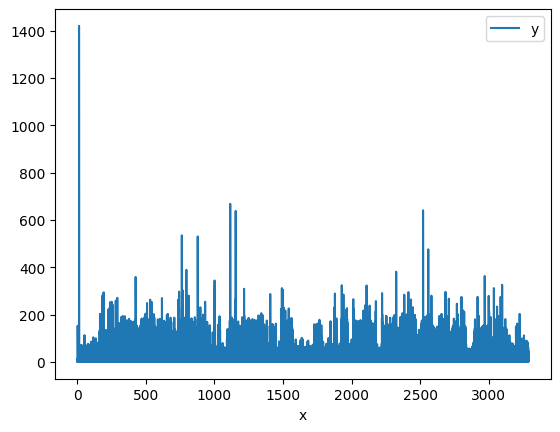

In [6]:
statement_to_df("select tick as x, micros_elapsed as y from server_ticks").plot("x", "y")

<Axes: xlabel='x'>

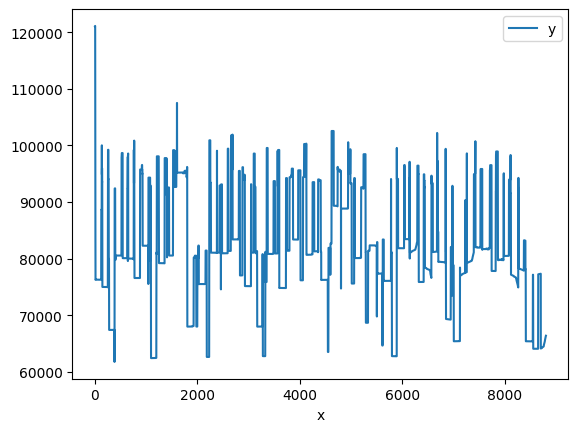

In [9]:
statement_to_df("select id as x, micros as y from pings").plot("x", "y")

array([[<Axes: title={'center': 'y'}>]], dtype=object)

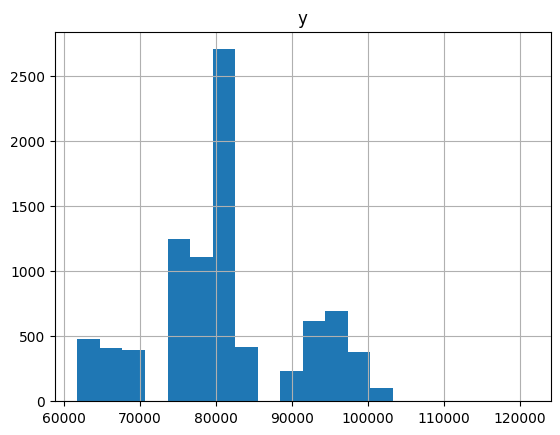

In [8]:
df = statement_to_df("select id as x, micros as y from pings limit 10000")
#df.plot(x='x', y='y')
df.hist(column='y', bins=20)

In [11]:
statement_to_df("select * from player_counts").head()

,id,game_id,tick,count,created_at
